# Analiza wpływu głębokości drzewa na F1-score

---

Celem zadania jest **zbadanie wpływu parametru `max_depth` drzewa decyzyjnego** na skuteczność klasyfikacji mierzoną **F1-score**.

---

**Zbiór danych:**

* **Zbiór**: `breast_cancer` z `sklearn.datasets`
* **Zadanie**: Klasyfikacja guzów jako złośliwych (`malignant`) lub łagodnych (`benign`)
* **Charakterystyka**:

  * Zbalansowane klasy,
  * Klasyfikacja binarna,
  * 30 cech numerycznych.

---

**Cel zadania:**

* Zidentyfikować wartość `max_depth`, która daje **najlepszy kompromis** między niedouczeniem a przeuczeniem.
* Dodatkowo przedstaw krzywą uczenia dla wybranej wartości `max_depth`

---

# Rozwiązanie

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Wczytanie danych
data = load_breast_cancer()
X = data.data
y = data.target

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<span style="color: red; font-weight: bold;">Wykres krzywej walidacyjnej</span>

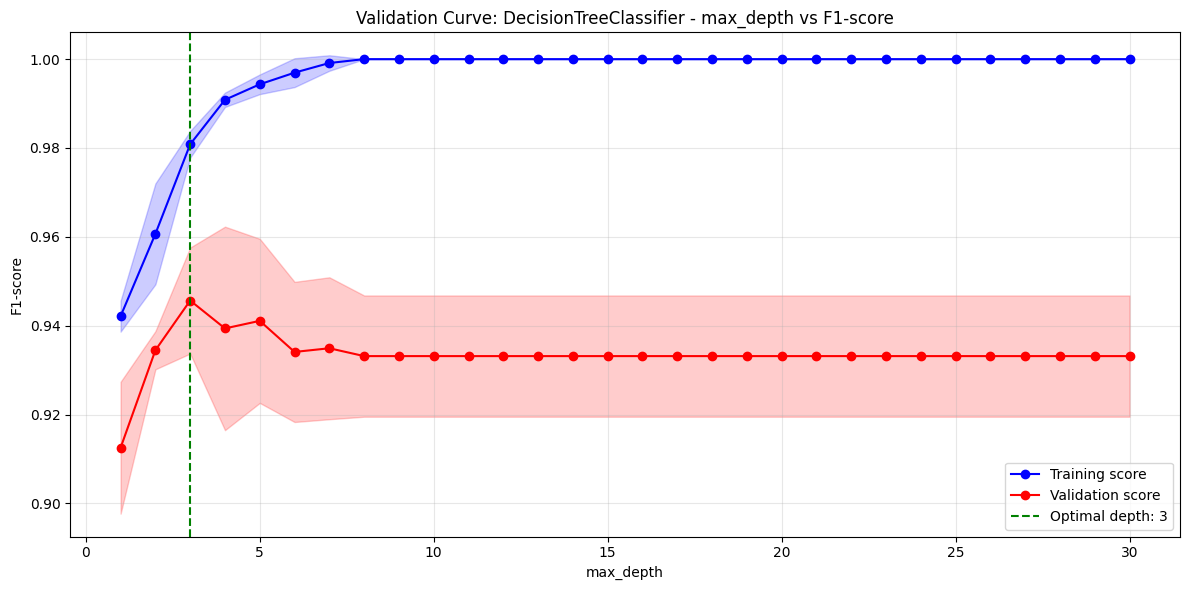

Optymalna głębokość: 3
Training F1-score: 0.9808
Validation F1-score: 0.9457


In [2]:
from sklearn.model_selection import validation_curve

param_range = np.arange(1, 31)

train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(param_range, train_mean, label="Training score", marker='o', color='blue')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.plot(param_range, test_mean, label="Validation score", marker='o', color='red')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color='red')

optimal_depth = param_range[np.argmax(test_mean)]
plt.axvline(optimal_depth, color='green', linestyle='--', label=f'Optimal depth: {optimal_depth}')

plt.xlabel("max_depth")
plt.ylabel("F1-score")
plt.title("Validation Curve: DecisionTreeClassifier - max_depth vs F1-score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optymalna głębokość: {optimal_depth}")
print(f"Training F1-score: {train_mean[optimal_depth-1]:.4f}")
print(f"Validation F1-score: {test_mean[optimal_depth-1]:.4f}")


<span style="color: red; font-weight: bold;">Wykres krzywej uczenia</span>

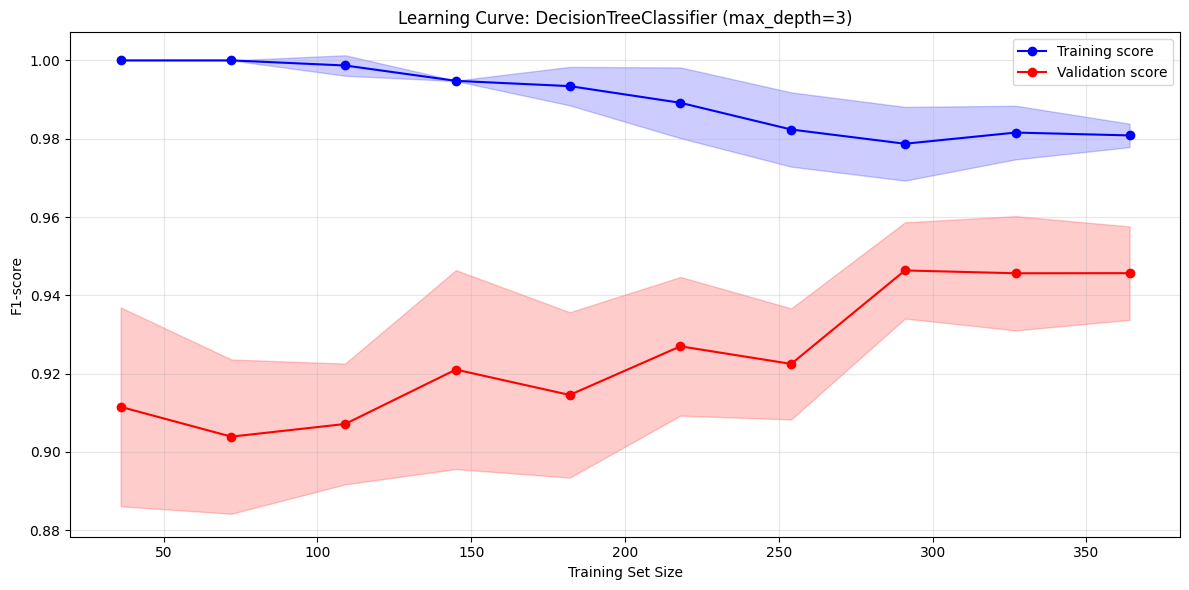


F1-score na zbiorze testowym: 0.9583


In [3]:
from sklearn.model_selection import learning_curve

model = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)

train_sizes, train_scores_lc, test_scores_lc = learning_curve(
    model,
    X_train, y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean_lc = np.mean(train_scores_lc, axis=1)
train_std_lc = np.std(train_scores_lc, axis=1)
test_mean_lc = np.mean(test_scores_lc, axis=1)
test_std_lc = np.std(test_scores_lc, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean_lc, label="Training score", marker='o', color='blue')
plt.fill_between(train_sizes, train_mean_lc - train_std_lc, train_mean_lc + train_std_lc, alpha=0.2, color='blue')
plt.plot(train_sizes, test_mean_lc, label="Validation score", marker='o', color='red')
plt.fill_between(train_sizes, test_mean_lc - test_std_lc, test_mean_lc + test_std_lc, alpha=0.2, color='red')

plt.xlabel("Training Set Size")
plt.ylabel("F1-score")
plt.title(f"Learning Curve: DecisionTreeClassifier (max_depth={optimal_depth})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

y_pred = model.fit(X_train, y_train).predict(X_test)
test_f1 = f1_score(y_test, y_pred)
print(f"\nF1-score na zbiorze testowym: {test_f1:.4f}")
